# `regionprops` benchmark — scikit-image side and comparison

Interactive companion to `benchmarks/python/bench_regionprops.py` and
`benchmarks/join_results.jl`. Runs the scikit-image side, joins it against the
Julia results, and explores the one property that disagrees.

**Run it with the project's environment**, so the pinned scikit-image is used:

```
cd benchmarks/python && uv run jupyter lab ../notebooks/02-comparison.ipynb
```

**Prerequisites:** `export_labels.jl` for the fixtures, and
`benchmark_regionprops.jl` if you want the speed join in section 4.

In [1]:
import csv
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.measure import regionprops, regionprops_table
from skimage.morphology import convex_hull_image

BENCH = Path.cwd()
while not (BENCH / "fixtures").is_dir() and BENCH != BENCH.parent:
    BENCH = BENCH.parent
FIXTURES, RESULTS = BENCH / "fixtures", BENCH / "results"

# Julia name -> scikit-image name, for the six properties that map 1:1.
PROPERTY_MAP = {
    "area": "area",
    "perimeter": "perimeter",
    "convex_area": "area_convex",
    "solidity": "solidity",
    "major_axis_length": "axis_major_length",
    "minor_axis_length": "axis_minor_length",
}
print("benchmarks dir:", BENCH)

benchmarks dir: /home/cpaniaguam/IceFloeTracker.jl/benchmarks


## 1. The shared fixture

Both languages read these exact bytes; the SHA-256 is asserted so a stale or
regenerated fixture fails loudly rather than producing a quietly mismatched
comparison.

In [2]:
def load_fixture(name):
    binpath, metapath = FIXTURES / f"labels_{name}.bin", FIXTURES / f"labels_{name}.json"
    meta = json.loads(metapath.read_text())
    digest = hashlib.sha256(binpath.read_bytes()).hexdigest()
    assert digest == meta["sha256"], f"{name}: fixture digest mismatch"
    labels = np.fromfile(binpath, dtype="<i4").reshape(meta["rows"], meta["cols"])
    return labels, meta

labels, meta = load_fixture("full")
print(f"{meta['name']}: {meta['rows']} x {meta['cols']} "
      f"({labels.size/1e6:.1f} Mpx), {meta['n_labels']} labels")

full: 5680 x 3392 (19.3 Mpx), 1910 labels


## 2. The scikit-image values

`regionprops_table` (Julia) keeps labels with `area > 1` — *strictly* greater — so
single-pixel regions are dropped; scikit-image keeps them. The same filter is
applied here, or the row sets would not line up and every statistic below
would be comparing different floes.

In [3]:
def skimage_values(labels, properties=tuple(PROPERTY_MAP.values())):
    props = tuple(dict.fromkeys(("label", "area") + tuple(properties)))
    table = regionprops_table(labels, properties=props)
    keep = table["area"] > 1                      # match Julia's minimum_area filter
    return pd.DataFrame({k: v[keep] for k, v in table.items()})

py = skimage_values(labels)
print(f"rows after the area > 1 filter: {len(py)}  (labels in fixture: {meta['n_labels']})")
py.head(8)

rows after the area > 1 filter: 1834  (labels in fixture: 1910)


,label,area,perimeter,area_convex,solidity,axis_major_length,axis_minor_length
0,1,790.0,150.710678,925.0,0.854054,35.624859,31.292491
1,2,11478.0,652.002092,13295.0,0.863332,162.246150,105.641235
2,3,407.0,98.769553,468.0,0.869658,35.107802,16.797603
3,4,261.0,64.870058,283.0,0.922261,21.875945,15.518071
4,5,256.0,66.284271,286.0,0.895105,22.691829,15.390667
5,6,170.0,51.798990,190.0,0.894737,16.321927,13.853178
6,7,327.0,74.526912,359.0,0.910864,27.180747,15.860723
7,8,285.0,72.769553,319.0,0.893417,28.328916,13.228463


## 3. Parity against the Julia values

Reads `results/values_julia_<size>.csv`, written by `benchmark_regionprops.jl`.
Non-finite rows are counted separately, never dropped silently or averaged in:
Julia's convex area is `NaN` below 4 px and where the hull degenerates, while
scikit-image always returns a number.

In [4]:
jl_path = RESULTS / "values_julia.csv"
assert jl_path.exists(), f"missing {jl_path} -- run benchmark_regionprops.jl first"
jl = pd.read_csv(jl_path)

assert list(jl["label"]) == list(py["label"]), (
    f"label sets differ: {len(jl)} Julia vs {len(py)} Python -- comparison refused")

rows = []
for jname, skname in PROPERTY_MAP.items():
    a, b = jl[jname].to_numpy(float), py[skname].to_numpy(float)
    ok = np.isfinite(a) & np.isfinite(b)
    scale = np.maximum(np.abs(a[ok]), np.abs(b[ok]))
    rel = np.where(scale == 0, 0.0, np.abs(a[ok] - b[ok]) / np.where(scale == 0, 1, scale))
    rows.append({
        "property": jname,
        "compared": int(ok.sum()),
        "non_comparable": int((~ok).sum()),
        "max_abs_diff": float(np.abs(a[ok] - b[ok]).max()) if ok.any() else np.nan,
        "max_rel_diff": float(rel.max()) if ok.any() else np.nan,
        "verdict": "match" if (ok.any() and rel.max() <= 1e-9) else "DIFFERS",
    })
parity = pd.DataFrame(rows)
parity

,property,compared,non_comparable,max_abs_diff,max_rel_diff,verdict
0,area,1834,0,0.000000e+00,0.000000e+00,match
1,perimeter,1834,0,1.136868e-13,3.702211e-16,match
2,convex_area,1819,15,2.890000e+02,3.076923e-01,DIFFERS
3,solidity,1819,15,3.076923e-01,3.076923e-01,DIFFERS
4,major_axis_length,1834,0,8.526513e-14,7.413768e-16,match
5,minor_axis_length,1834,0,1.421085e-13,2.913773e-15,match


Four of the six agree to roughly machine precision. `convex_area` and
`solidity` do not — section 5 is about why.

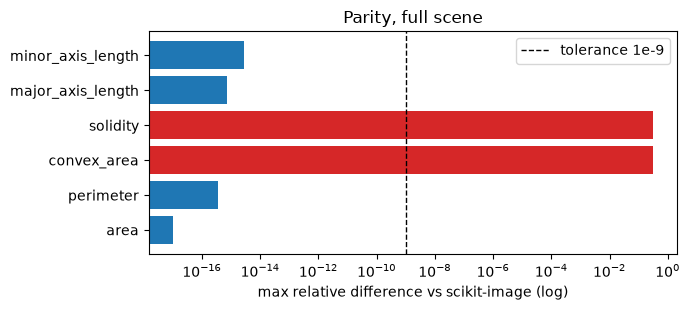

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
d = parity.set_index("property")["max_rel_diff"].clip(lower=1e-17)
colors = ["tab:red" if v > 1e-9 else "tab:blue" for v in d]
ax.barh(d.index, d.values, color=colors)
ax.set_xscale("log")
ax.axvline(1e-9, color="k", ls="--", lw=1, label="tolerance 1e-9")
ax.set_xlabel("max relative difference vs scikit-image (log)")
ax.set_title("Parity, full scene")
ax.legend()
plt.tight_layout()

## 4. Speed

Both result files use the **minimum** as the estimator — pytest-benchmark
reports a mean too, and comparing Julia's minimum against it would flatter
Julia for free. Run the two harnesses first to populate these.

In [6]:
jpath, ppath = RESULTS / "julia.json", RESULTS / "python.json"
if not (jpath.exists() and ppath.exists()):
    print("Run benchmark_regionprops.jl and bench_regionprops.py to populate this section.")
    speed = None
else:
    jrows = {(r["case"], r["property"], r["size"]): r
             for r in json.loads(jpath.read_text())["results"]}
    prows = {}
    for b in json.loads(ppath.read_text())["benchmarks"]:
        i = b["extra_info"]
        if "case" in i:
            prows[(i["case"], i["property"], i["size"])] = b["stats"]["min"]

    recs = []
    for key, j in jrows.items():
        if key in prows:
            recs.append({"case": key[0], "property": key[1], "size": key[2],
                         "julia_s": j["min_s"], "skimage_s": prows[key],
                         "ratio_py_over_jl": prows[key] / j["min_s"],
                         "julia_alloc_mib": j["median_mib"]})
    speed = pd.DataFrame(recs).sort_values("property").reset_index(drop=True)
speed

,case,property,size,julia_s,skimage_s,ratio_py_over_jl,julia_alloc_mib
0,combined,all_properties,full,3.883427,0.877042,0.225842,4788.040710
1,single,area,full,0.122479,0.058191,0.475114,0.179420
2,single,convex_area,full,2.466181,0.569950,0.231106,3691.618034
3,single,major_axis_length,full,0.469698,0.294719,0.627464,872.374306
4,single,minor_axis_length,full,0.379531,0.293468,0.773240,872.410194
5,single,perimeter,full,2.474817,0.146396,0.059154,3804.163414
6,single,solidity,full,2.415975,0.574237,0.237683,3691.632202


## 5. Why `convex_area` differs

`skimage.morphology.convex_hull_image` defaults to `offset_coordinates=True`,
which replaces each pixel `(r, c)` with four points at `(r±0.5, c)` and
`(r, c±0.5)` before hulling — so the hull encloses the pixels' *extents*.
IceFloeTracker hulls the bare pixel *centres*
(`ImageMorphology.convexhull` returns integer `CartesianIndex` vertices).

That single default accounts for the entire gap.

In [7]:
# Every floe, both ways. The hypothesis: Julia == skimage with offsets OFF.
exact_off = exact_on = 0
for p in regionprops(labels):
    if p.area <= 1:
        continue
    j = float(jl.loc[jl["label"] == p.label, "convex_area"].iloc[0])
    exact_off += convex_hull_image(p.image, offset_coordinates=False).sum() == j
    exact_on += p.area_convex == j

n = len(jl)
print(f"floes compared: {n}")
print(f"  Julia == skimage(offset_coordinates=False) : {exact_off}/{n} exact")
print(f"  Julia == skimage(default, offsets ON)      : {exact_on}/{n} exact")

/tmp/ipykernel_615443/2492409842.py:7: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(2) to construct initial simplex (need 3)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 680405677  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _maxoutside  0

  exact_off += convex_hull_image(p.image, offset_coordinates=False).sum() == j
/tmp/ipykernel_615443/2492409842.py:7: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6013 qhull input error: input is less than 2-dimensional since all points have the same x coordinate    0

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 680405677  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width  5  Error-roundoff 3.4e-15  _one-merge 1.7e-14
  _near-inside 8.4e-14  Visible-distance 6.7e-15  U-max-coplanar 6.7e-15
  Width-o

/tmp/ipykernel_615443/2492409842.py:7: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(2) to construct initial simplex (need 3)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 680422484  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _maxoutside  0

  exact_off += convex_hull_image(p.image, offset_coordinates=False).sum() == j


floes compared: 1834
  Julia == skimage(offset_coordinates=False) : 1819/1834 exact
  Julia == skimage(default, offsets ON)      : 1/1834 exact


### Seen on one shape

A T: the hull edge cuts diagonally across background, so half a pixel of
inflation changes which centres fall inside. Convex shapes agree trivially —
dilating a shape that already fills its hull adds no new centres.

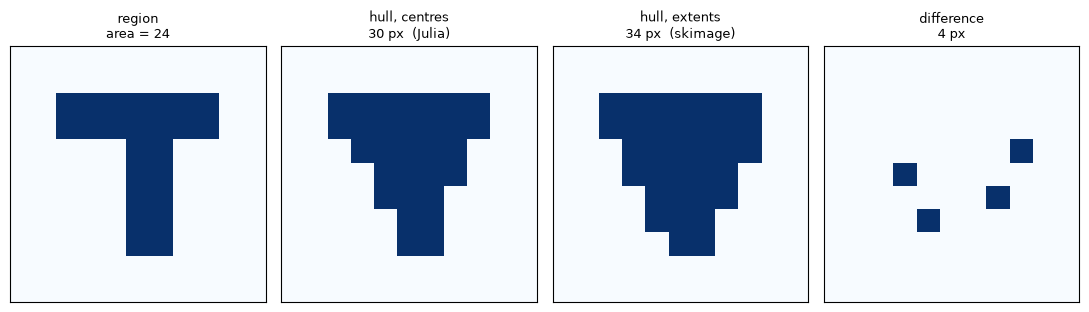

In [8]:
T = np.zeros((11, 11), dtype=bool)
T[2:4, 2:9] = True
T[2:9, 5:7] = True

hull_off = convex_hull_image(T, offset_coordinates=False)   # what Julia computes
hull_on = convex_hull_image(T, offset_coordinates=True)     # scikit-image default

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, (img, title) in zip(axes, [
    (T, f"region\narea = {T.sum()}"),
    (hull_off, f"hull, centres\n{hull_off.sum()} px  (Julia)"),
    (hull_on, f"hull, extents\n{hull_on.sum()} px  (skimage)"),
    (hull_on & ~hull_off, f"difference\n{(hull_on & ~hull_off).sum()} px"),
]):
    ax.imshow(img, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

### How the gap scales

The inflation adds pixels along the hull boundary, which grows as the
perimeter while area grows as its square — so the *relative* error shrinks as
floes get bigger. That is why the parity gap is worst on small floes.

/tmp/ipykernel_615443/424391718.py:5: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(2) to construct initial simplex (need 3)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 680439291  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _maxoutside  0

  off = convex_hull_image(p.image, offset_coordinates=False).sum()
/tmp/ipykernel_615443/424391718.py:5: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6013 qhull input error: input is less than 2-dimensional since all points have the same x coordinate    0

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 680439291  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width  5  Error-roundoff 3.4e-15  _one-merge 1.7e-14
  _near-inside 8.4e-14  Visible-distance 6.7e-15  U-max-coplanar 6.7e-15
  Width-outside 1.3e-14

min    0.00000
50%    0.06495
max    1.00000


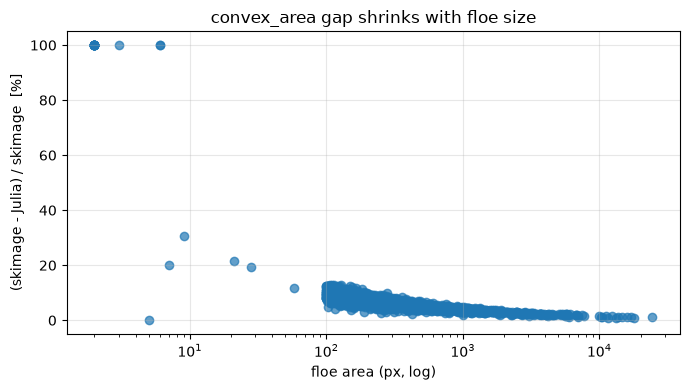

In [9]:
recs = []
for p in regionprops(labels):
    if p.area <= 1:
        continue
    off = convex_hull_image(p.image, offset_coordinates=False).sum()
    recs.append({"area": p.area, "julia_like": off, "skimage": p.area_convex,
                 "rel_gap": (p.area_convex - off) / p.area_convex})
gap = pd.DataFrame(recs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(gap["area"], gap["rel_gap"] * 100, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("floe area (px, log)")
ax.set_ylabel("(skimage - Julia) / skimage  [%]")
ax.set_title("convex_area gap shrinks with floe size")
ax.grid(alpha=0.3)
plt.tight_layout()
print(gap["rel_gap"].describe()[["min", "50%", "max"]].to_string())

## 6. Excluded from this study

| property | why |
|---|---|
| `circularity` | No scikit-image counterpart — it is `area/perimeter` here, not the dimensionless `4πA/P²`. |
| `centroid`, `bbox` | Differ by indexing convention only (1-based inclusive vs 0-based half-open). |
| `orientation` | Sign and reference axis differ. |
| `mask` | An array, not a scalar to diff. |
| `convex_area` via `PolygonConvexArea` | A continuous polygon area over pixel centres, not commensurable with a pixel count — `solidity` built on it exceeds 1 for 57% of real floes — and scikit-image has no polygon-integration variant. See `issue_polygon_solidity.md`. |

All measurements pin `convex_area_algorithm=PixelConvexArea()`.